In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd



In [2]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error, r2_score

In [3]:
np.random.seed(42)
blood_pressure = 2 * np.random.rand(100, 1)
inflammation_level = 4 + 3 * blood_pressure + np.random.randn(100, 1)



data = pd.DataFrame({
    'Blood Pressure (mmHg)': blood_pressure.flatten(),
    'Inflammation Level (Biomarker)': inflammation_level.flatten()
})

data.head()

,Blood Pressure (mmHg),Inflammation Level (Biomarker)
0,0.749080,6.334288
1,1.901429,9.405278
2,1.463988,8.483724
3,1.197317,5.604382
4,0.312037,4.716440


In [4]:
data.columns

Index(['Blood Pressure (mmHg)', 'Inflammation Level (Biomarker)'], dtype='object')

In [5]:
data.iloc[:,0]

,Blood Pressure (mmHg)
0,0.749080
1,1.901429
2,1.463988
3,1.197317
4,0.312037
...,...
95,0.987591
96,1.045466
97,0.855082
98,0.050838


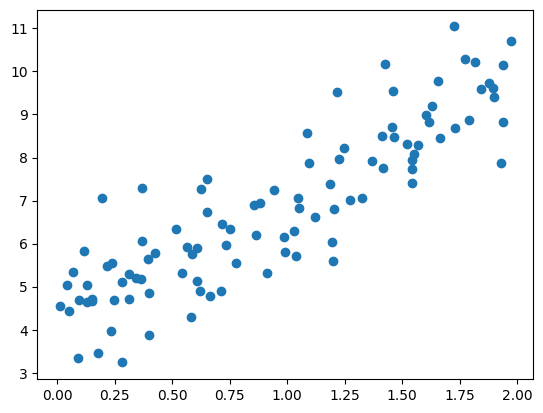

In [6]:
plt.scatter(data['Blood Pressure (mmHg)'], data['Inflammation Level (Biomarker)'])

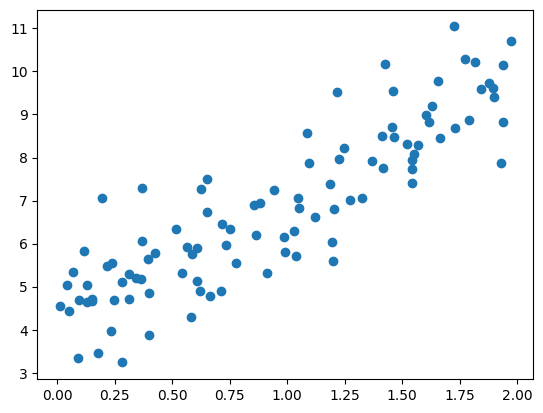

In [7]:
plt.scatter(data.iloc[:,0], data.iloc[:,1])

/tmp/ipython-input-1968582016.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


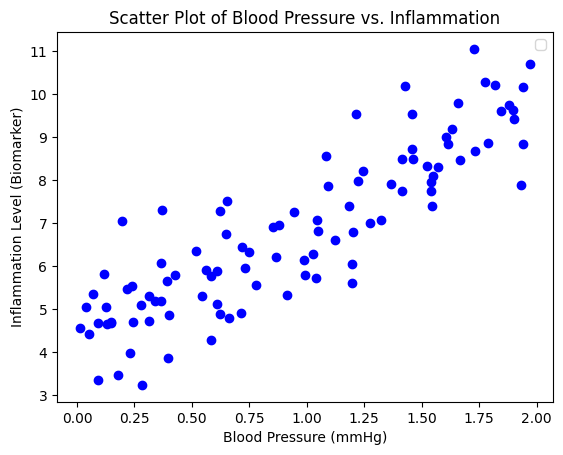

In [8]:
plt.scatter(data['Blood Pressure (mmHg)'], data['Inflammation Level (Biomarker)'],
            color='blue')
plt.xlabel('Blood Pressure (mmHg)')
plt.ylabel('Inflammation Level (Biomarker)')
plt.title('Scatter Plot of Blood Pressure vs. Inflammation')
plt.legend()
plt.show()

In [9]:
bp_train, bp_test, infl_train, infl_test = train_test_split(blood_pressure, inflammation_level,
                                                            test_size=0.2)

In [11]:
#model

In [12]:
model = LinearRegression()
model.fit(bp_train, infl_train)

LinearRegression()

In [13]:
model.coef_

array([[2.77456502]])

In [14]:
infl_pred = model.predict(bp_test)
infl_pred

array([[8.40644372],
       [4.47925782],
       [8.91603742],
       [4.26761831],
       [8.18849384],
       [4.53744767],
       [5.22926343],
       [5.85224561],
       [6.7469463 ],
       [9.50691546],
       [4.8037703 ],
       [8.42787711],
       [8.57805964],
       [8.17524383],
       [4.66855953],
       [5.15234568],
       [4.99233199],
       [4.2407903 ],
       [9.60292822],
       [7.58532663]])

In [15]:
infl_pred = pd.Series(np.squeeze(infl_pred))

In [16]:
type(infl_pred)

pandas.core.series.Series

In [17]:
infl_test

array([[ 7.94759736],
       [ 5.03790371],
       [11.04439507],
       [ 4.42920556],
       [ 8.48372443],
       [ 4.67652161],
       [ 3.87183748],
       [ 4.89121226],
       [ 7.24607048],
       [ 8.82697144],
       [ 4.69751764],
       [ 8.08449921],
       [ 8.99781574],
       [ 9.53623265],
       [ 7.0492748 ],
       [ 7.29958236],
       [ 4.71643995],
       [ 5.03890908],
       [10.70314449],
       [ 8.21362168]])

In [18]:
rez = pd.DataFrame([np.squeeze( infl_test), np.squeeze( infl_pred)]).T
rez.columns = ["test","pred"]
rez

,test,pred
0,7.947597,8.406444
1,5.037904,4.479258
2,11.044395,8.916037
3,4.429206,4.267618
4,8.483724,8.188494
5,4.676522,4.537448
6,3.871837,5.229263
7,4.891212,5.852246
8,7.246070,6.746946
9,8.826971,9.506915


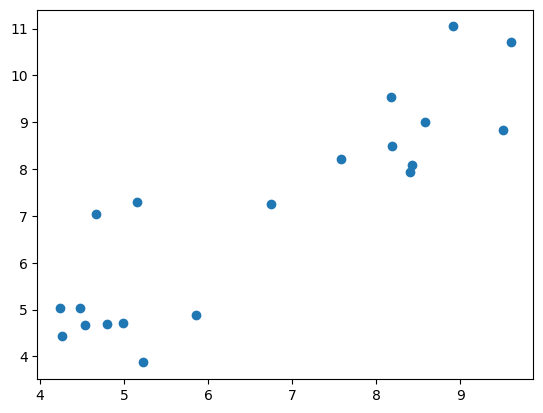

In [19]:
plt.scatter(infl_pred, infl_test)

In [20]:
mse = mean_squared_error(infl_test, infl_pred)
r2 = r2_score(infl_test, infl_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared Score: {r2:.2f}")

Mean Squared Error: 1.17
R-squared Score: 0.75


In [ ]:
#importing dataset

In [22]:
dataset = pd.read_csv('https://github.com/bio-chem-info/python_course/raw/refs/heads/main/regression_data.csv')
X = dataset.iloc[:, :-1]
y = dataset.iloc[:, -1]

<Axes: >

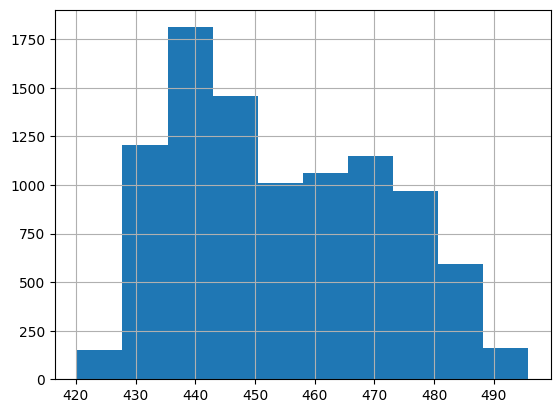

In [23]:
y.name = "NO2"
y.hist()

In [24]:
dataset.corr()


,AT,V,AP,RH,PE
AT,1.000000,0.844107,-0.507549,-0.542535,-0.948128
V,0.844107,1.000000,-0.413502,-0.312187,-0.869780
AP,-0.507549,-0.413502,1.000000,0.099574,0.518429
RH,-0.542535,-0.312187,0.099574,1.000000,0.389794
PE,-0.948128,-0.869780,0.518429,0.389794,1.000000


In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

In [26]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

In [27]:
pd.Series(np.squeeze(regressor.coef_), index=X.columns)

,0
AT,-1.969508
V,-0.237671
AP,0.064740
RH,-0.157826


In [28]:
regressor.intercept_

np.float64(451.949503920339)

<Axes: >

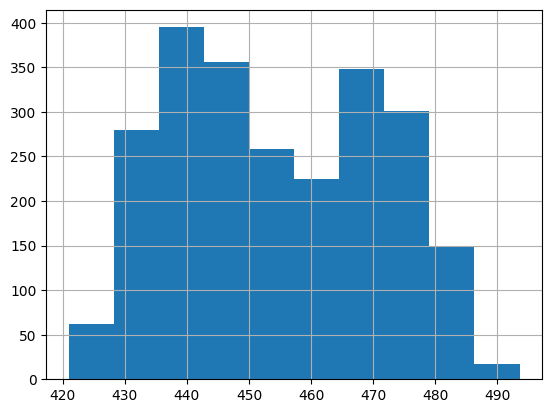

In [29]:
y_pred = regressor.predict(X_test)
y_pred = pd.Series(y_pred, index=y_test.index, name='yhat')
y_pred.hist()

In [30]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.9323789104734466

In [31]:
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmse

np.float64(4.453331075913261)

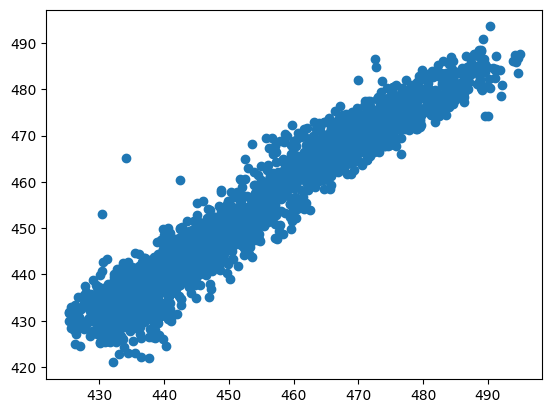

In [32]:
results = pd.concat([y_test, y_pred], axis=1)
results
plt.scatter(results.NO2, results.yhat)